In [ ]:
from encodec import EncodecModel
from encodec.utils import convert_audio
import IPython.display

import torchaudio
import torch

# Instantiate a pretrained EnCodec model
model = EncodecModel.encodec_model_48khz()
# The number of codebooks used will be determined bythe bandwidth selected.
# E.g. for a bandwidth of 6kbps, `n_q = 8` codebooks are used.
# Supported bandwidths are 1.5kbps (n_q = 2), 3 kbps (n_q = 4), 6 kbps (n_q = 8) and 12 kbps (n_q =16) and 24kbps (n_q=32).
# For the 48 kHz model, only 3, 6, 12, and 24 kbps are supported. The number
# of codebooks for each is half that of the 24 kHz model as the frame rate is twice as much.
model.set_target_bandwidth(24)

# Load and pre-process the audio waveform
wav, sr = torchaudio.load("amen-break.wav")  # Load your audio file here
wav = convert_audio(wav, sr, model.sample_rate, model.channels)
wav = wav.unsqueeze(0)

# Extract discrete codes from EnCodec
with torch.no_grad():
    encoded_frames = model.encode(wav)
codes = torch.cat([encoded[0] for encoded in encoded_frames], dim=-1)  # [B, n_q, T]

# decodes the discrete codes back to a waveform
with torch.no_grad():
    decoded_frames = model.decode(codes)
decoded_wav = decoded_frames.squeeze(0)  # [channels, time]
# Listen to the original and reconstructed audio
print('Original')
IPython.display.display(IPython.display.Audio(wav.squeeze().cpu().numpy(), rate=model.sample_rate))

print('Decoded')
IPython.display.display(IPython.display.Audio(decoded_wav.cpu().numpy(), rate=model.sample_rate))


In [ ]:
import encodec_helper as eh
import plot_utils as pu


device = "cuda" if torch.cuda.is_available() else "cpu"
model = eh.get_encodec_model(bitrate_kbps=24, target_model=48)

original, reconstructed = eh.get_original_and_reconstructed_audio(
	audio_file_path="amen-break.wav", model=model, device=device, return_torch_tensors=False
	)
original_tensor, reconstructed_tensor = eh.get_original_and_reconstructed_audio(
	audio_file_path="amen-break.wav", model=model, device=device, return_torch_tensors=True
	)

pu.play_audio(original, model.sample_rate, title="Original Audio")

Original Audio


In [7]:
pu.play_audio(reconstructed, model.sample_rate, title="Reconstructed Audio")


Reconstructed Audio


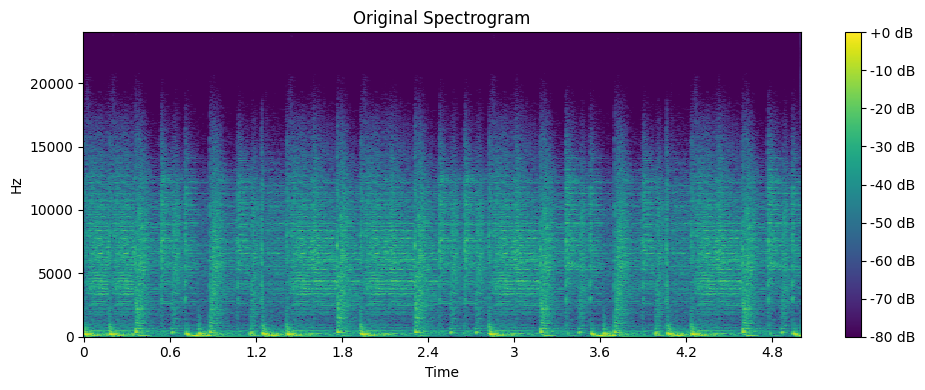

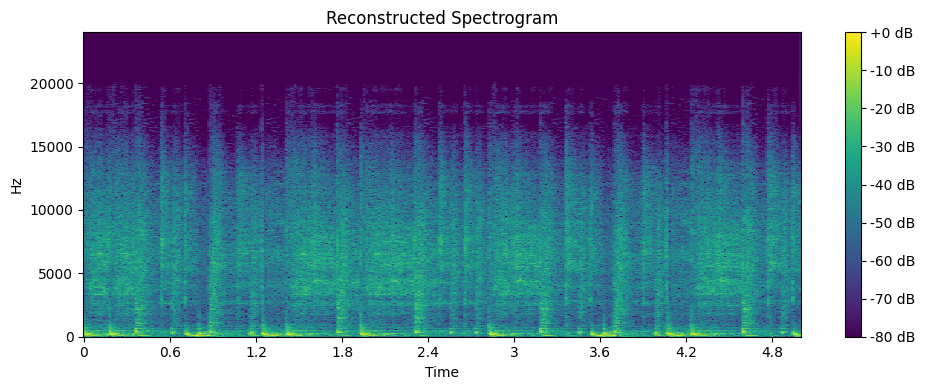

In [8]:
pu.plot_normal_spectrogram(original_tensor, model.sample_rate, title="Original Spectrogram")
pu.plot_normal_spectrogram(reconstructed_tensor, model.sample_rate, title="Reconstructed Spectrogram")